# Notebook 27 - Quick visual checkpoint: fascicle angle and length

This notebook is intentionally not a deep debug notebook.

The goal is to answer the practical question:

> Does the current Python signal look usable compared with MATLAB/UltraTimTrack, especially for fascicle angle and fascicle length over time?

Important interpretation:

- MATLAB `Fdat.geofeatures.alpha` / `faslen` are TimTrack-style frame-by-frame intermediate values.
- MATLAB `Fdat.Region.ANG` / `FL` are final UltraTimTrack region outputs after the Kalman/UltraTimTrack pipeline.
- Current Python notebook 23 is still mostly the TimTrack-style path: MATLAB-style `dohough + weighted_median` alpha on the current Python fascicle mask, plus Python aponeurosis-derived length estimates.

So this notebook shows both MATLAB references when useful, instead of pretending there is only one truth signal.

## Article context

From the UltraTimTrack article, the target is not perfect reproduction of a noiseless ground truth. The authors explicitly evaluate tracking accuracy, noise, and drift. The main design idea is to combine a low-noise optical-flow estimate with a drift-free line-detection estimate through a Kalman filter.

Their reported validation numbers are useful context: UltraTimTrack had low accumulated deviation and low cycle-to-cycle variability, and its root-mean-square deviations from manual tracking were on the order of a few millimeters for fascicle length and around one degree for fascicle angle in the cited comparison sequences.

So if Python is smoother or visually more plausible than MATLAB in some contraction regions, that is not automatically bad. The real question becomes: is it biologically plausible, stable, low-drift, and close enough to the MATLAB/manual scale of error?

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_final_region_arrays,
    extract_geofeature_arrays,
    load_matlab_result,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY23_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_METRICS = OUT_DIR / "notebook27_quick_angle_length_metrics.csv"
OUT_NPZ = OUT_DIR / "notebook27_quick_angle_length_arrays.npz"

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

for path in [VIDEO_PATH, MATLAB_RESULT, PY23_NPZ]:
    print(path, "exists=", path.exists())

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz exists= True


In [2]:
mat = load_matlab_result(MATLAB_RESULT)
mat_geo = extract_geofeature_arrays(mat)
mat_region = extract_final_region_arrays(mat)
py = np.load(PY23_NPZ)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
ret, frame0 = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")

image_height_px = frame0.shape[0]
image_depth_mm = float(mat_region["image_depth_mm"])
mm_per_px = image_depth_mm / image_height_px

n = min(
    len(mat_geo["alpha_deg"]),
    len(mat_region["fascicle_angle_deg"]),
    len(py["fascicle_angle_deg"]),
)

time_s = np.asarray(py["time_s"][:n], dtype=float)
frames = np.asarray(py["frame"][:n], dtype=int)

mat_alpha = np.asarray(mat_geo["alpha_deg"][:n], dtype=float)
mat_faslen_px = np.asarray(mat_geo["faslen_px"][:n], dtype=float)
mat_region_ang = np.asarray(mat_region["fascicle_angle_deg"][:n], dtype=float)
mat_region_fl_mm = np.asarray(mat_region["length_mm"][:n], dtype=float)
mat_region_pen = np.asarray(mat_region["pennation_deg"][:n], dtype=float)

py_alpha = np.asarray(py["fascicle_angle_deg"][:n], dtype=float)
py_phi = np.asarray(py["pennation_angle_deg"][:n], dtype=float)
py_formula_len_px = np.asarray(py["matlab_formula_fascicle_length_px"][:n], dtype=float)
py_selected_len_px = np.asarray(py["fascicle_length_px"][:n], dtype=float)
py_formula_len_mm = py_formula_len_px * mm_per_px
py_selected_len_mm = py_selected_len_px * mm_per_px

print("Aligned frames:", n)
print("fps:", fps)
print("image_height_px:", image_height_px)
print("image_depth_mm:", image_depth_mm)
print("mm_per_px:", mm_per_px)

Aligned frames: 2666
fps: 33.341
image_height_px: 562
image_depth_mm: 50.7
mm_per_px: 0.09021352313167261


## 1. Fascicle angle over time

This plot intentionally shows both MATLAB angle references:

- `MATLAB Region.ANG`: final UltraTimTrack output.
- `MATLAB geofeatures.alpha`: TimTrack module intermediate.
- `Python current alpha`: current notebook 23 `dohough + weighted_median` estimate.

If the Python curve looks smoother or slightly higher during contraction, that is a scientific interpretation question, not automatically an implementation failure.

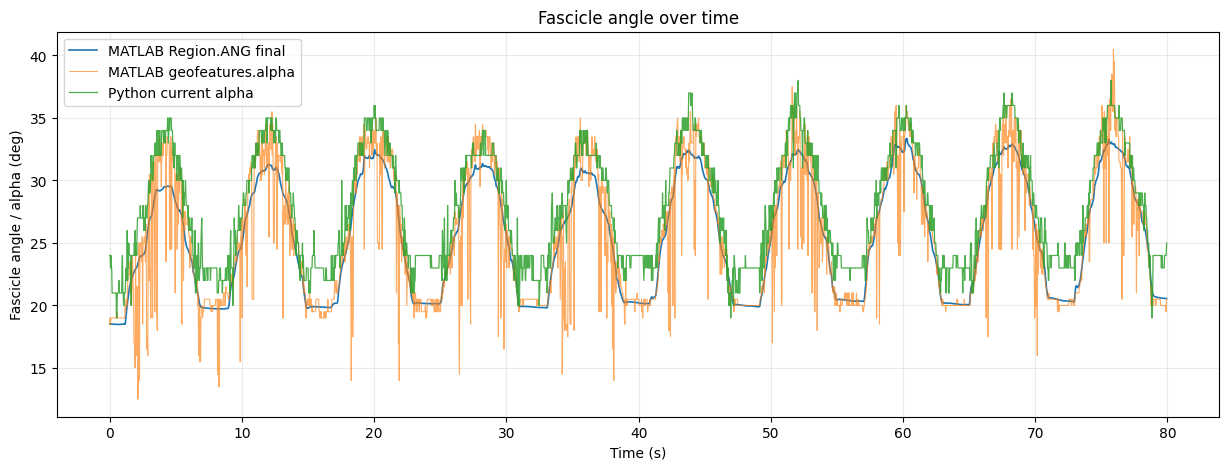

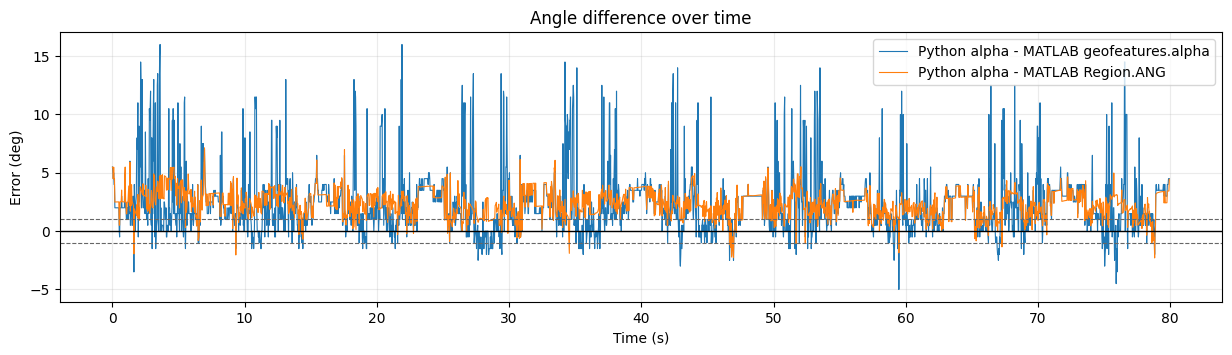

In [3]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_s, mat_region_ang, label="MATLAB Region.ANG final", linewidth=1.2)
ax.plot(time_s, mat_alpha, label="MATLAB geofeatures.alpha", linewidth=0.8, alpha=0.65)
ax.plot(time_s, py_alpha, label="Python current alpha", linewidth=0.9, alpha=0.85)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fascicle angle / alpha (deg)")
ax.set_title("Fascicle angle over time")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(time_s, py_alpha - mat_alpha, label="Python alpha - MATLAB geofeatures.alpha", linewidth=0.8)
ax.plot(time_s, py_alpha - mat_region_ang, label="Python alpha - MATLAB Region.ANG", linewidth=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(1, color="0.4", linestyle="--", linewidth=0.8)
ax.axhline(-1, color="0.4", linestyle="--", linewidth=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Error (deg)")
ax.set_title("Angle difference over time")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## 2. Zooms: rest-like and contraction-like portions

These zooms are not a formal cycle analysis. They are quick visual checks so we can see the difference between the lower-angle/rest regions and the higher-angle/contraction regions.

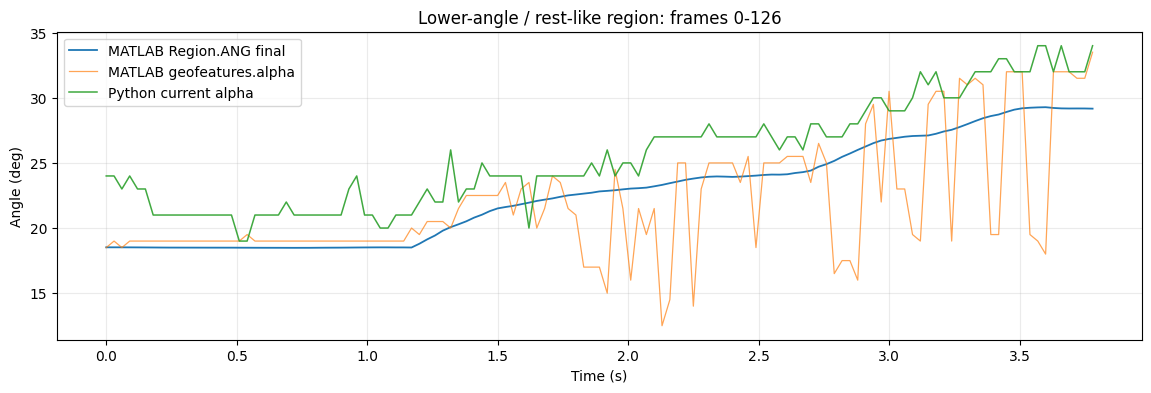

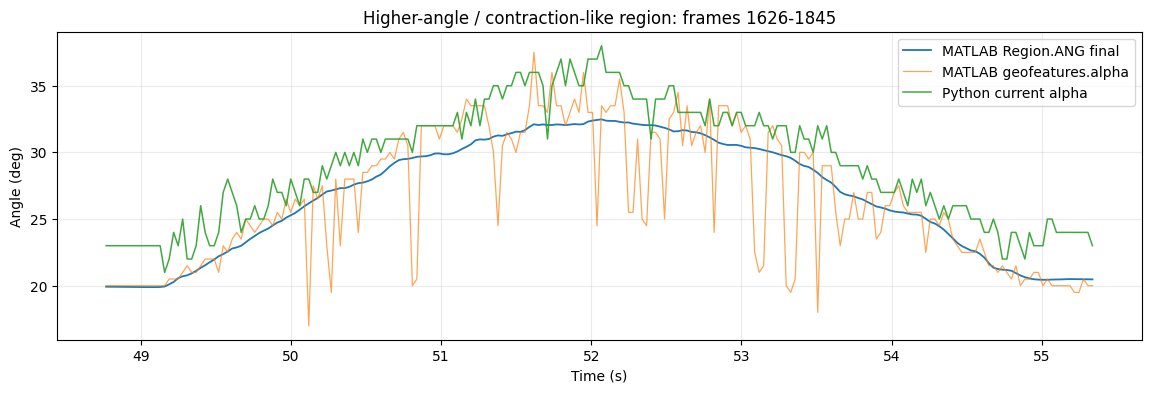

In [4]:
low_center = int(np.nanargmin(py_alpha))
high_center = int(np.nanargmax(py_alpha))
window = 220

zoom_specs = [
    ("Lower-angle / rest-like region", max(0, low_center - window // 2), min(n, low_center + window // 2)),
    ("Higher-angle / contraction-like region", max(0, high_center - window // 2), min(n, high_center + window // 2)),
]

for title, start, stop in zoom_specs:
    fig, ax = plt.subplots(figsize=(14, 4))
    sl = slice(start, stop)
    ax.plot(time_s[sl], mat_region_ang[sl], label="MATLAB Region.ANG final", linewidth=1.3)
    ax.plot(time_s[sl], mat_alpha[sl], label="MATLAB geofeatures.alpha", linewidth=0.9, alpha=0.7)
    ax.plot(time_s[sl], py_alpha[sl], label="Python current alpha", linewidth=1.1, alpha=0.9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (deg)")
    ax.set_title(f"{title}: frames {frames[start]}-{frames[stop - 1]}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

## 3. Fascicle length over time

Length is more complicated than angle because we currently have two Python length-like quantities:

- `Python formula length`: `thickness / sin(phi)` using Python alpha and Python aponeurosis geometry. This is the MATLAB-style length formula path.
- `Python selected-segment length`: length of the selected OpenCV fascicle segment between aponeuroses. This is visually useful, but it is not the MATLAB final formula path and has known selected-line instability.

The first plot uses pixels against MATLAB `geofeatures.faslen`. The second plot converts to millimeters and compares against MATLAB final `Region.FL`.

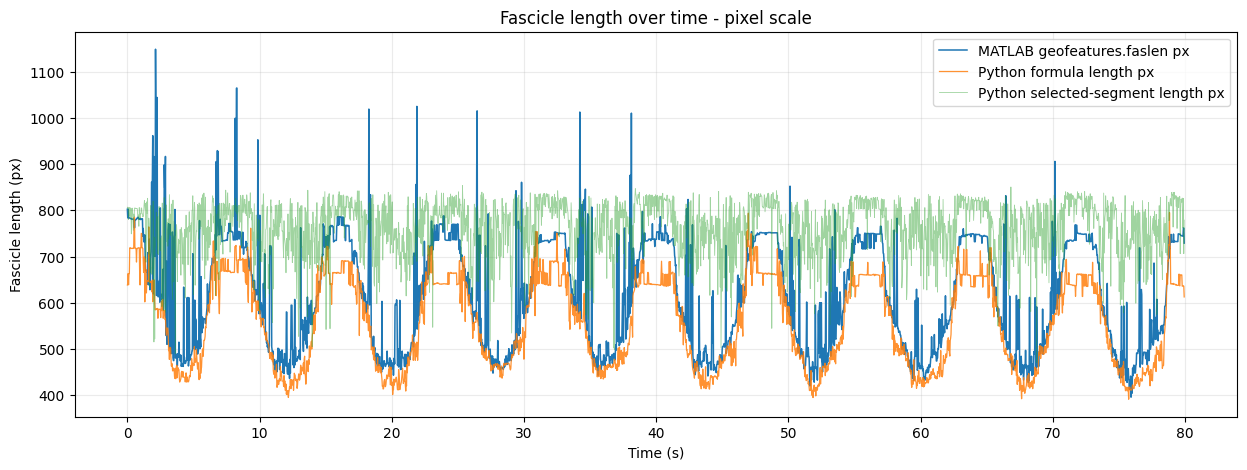

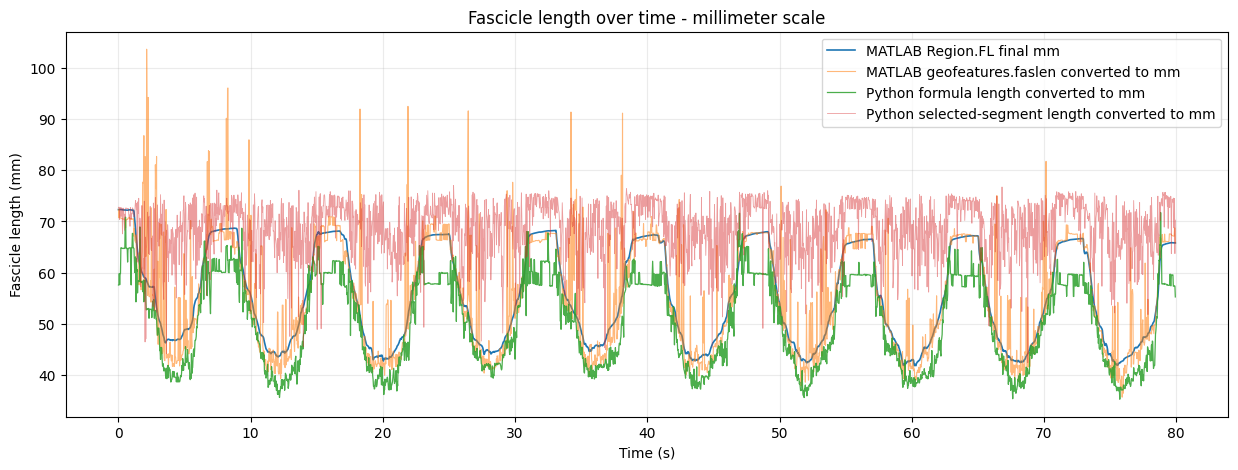

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_s, mat_faslen_px, label="MATLAB geofeatures.faslen px", linewidth=1.1)
ax.plot(time_s, py_formula_len_px, label="Python formula length px", linewidth=0.9, alpha=0.85)
ax.plot(time_s, py_selected_len_px, label="Python selected-segment length px", linewidth=0.6, alpha=0.45)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fascicle length (px)")
ax.set_title("Fascicle length over time - pixel scale")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_s, mat_region_fl_mm, label="MATLAB Region.FL final mm", linewidth=1.2)
ax.plot(time_s, mat_faslen_px * mm_per_px, label="MATLAB geofeatures.faslen converted to mm", linewidth=0.8, alpha=0.55)
ax.plot(time_s, py_formula_len_mm, label="Python formula length converted to mm", linewidth=0.9, alpha=0.85)
ax.plot(time_s, py_selected_len_mm, label="Python selected-segment length converted to mm", linewidth=0.6, alpha=0.45)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fascicle length (mm)")
ax.set_title("Fascicle length over time - millimeter scale")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## 4. Metrics: close enough is about scale, not perfection

These metrics are here to keep the visual interpretation honest. They should be read with the article context in mind: MATLAB/UltraTimTrack is an algorithmic reference, not a perfect biological ground truth.

In [6]:
def metric_row(name, reference, estimate, unit):
    row = {"comparison": name, "unit": unit}
    row.update(compute_metrics(reference, estimate))
    return row

metrics = pd.DataFrame([
    metric_row("angle: Python alpha vs MATLAB geofeatures.alpha", mat_alpha, py_alpha, "deg"),
    metric_row("angle: Python alpha vs MATLAB Region.ANG", mat_region_ang, py_alpha, "deg"),
    metric_row("angle: MATLAB geofeatures.alpha vs MATLAB Region.ANG", mat_region_ang, mat_alpha, "deg"),
    metric_row("length: Python formula px vs MATLAB geofeatures.faslen", mat_faslen_px, py_formula_len_px, "px"),
    metric_row("length: Python selected segment px vs MATLAB geofeatures.faslen", mat_faslen_px, py_selected_len_px, "px"),
    metric_row("length: Python formula mm vs MATLAB Region.FL", mat_region_fl_mm, py_formula_len_mm, "mm"),
    metric_row("length: Python selected segment mm vs MATLAB Region.FL", mat_region_fl_mm, py_selected_len_mm, "mm"),
])

metrics.to_csv(OUT_METRICS, index=False)
display(metrics)
print("Saved metrics:", OUT_METRICS)

,comparison,unit,n,bias,mae,rmse,corr
0,angle: Python alpha vs MATLAB geofeatures.alpha,deg,2666,2.319392,2.526819,3.537244,0.866061
1,angle: Python alpha vs MATLAB Region.ANG,deg,2666,2.351215,2.382489,2.612432,0.968938
2,angle: MATLAB geofeatures.alpha vs MATLAB Regi...,deg,2666,0.031823,1.450930,2.465613,0.887430
3,length: Python formula px vs MATLAB geofeature...,px,2666,-59.888178,62.439799,87.690616,0.843224
4,length: Python selected segment px vs MATLAB g...,px,2666,146.038386,155.143503,183.660677,0.373588
5,length: Python formula mm vs MATLAB Region.FL,mm,2666,-4.993746,5.115188,5.730871,0.954772
6,length: Python selected segment mm vs MATLAB R...,mm,2666,13.583614,13.804963,16.078374,0.428447


Saved metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook27_quick_angle_length_metrics.csv


## 5. Simple smoothness / noise proxy

The article separates drift and noise. This is not a full reproduction of their cycle-to-cycle analysis, but it is a useful quick check: frame-to-frame difference variability.

A lower value here usually means a smoother signal, but overly smooth can also mean missed real motion. Use it together with the plots.

In [7]:
def diff_std(x):
    x = np.asarray(x, dtype=float)
    d = np.diff(x)
    return float(np.nanstd(d))

smoothness = pd.DataFrame([
    {"signal": "MATLAB Region.ANG", "unit": "deg/frame", "frame_to_frame_std": diff_std(mat_region_ang)},
    {"signal": "MATLAB geofeatures.alpha", "unit": "deg/frame", "frame_to_frame_std": diff_std(mat_alpha)},
    {"signal": "Python current alpha", "unit": "deg/frame", "frame_to_frame_std": diff_std(py_alpha)},
    {"signal": "MATLAB Region.FL", "unit": "mm/frame", "frame_to_frame_std": diff_std(mat_region_fl_mm)},
    {"signal": "Python formula length", "unit": "mm/frame", "frame_to_frame_std": diff_std(py_formula_len_mm)},
    {"signal": "Python selected-segment length", "unit": "mm/frame", "frame_to_frame_std": diff_std(py_selected_len_mm)},
])

display(smoothness)

,signal,unit,frame_to_frame_std
0,MATLAB Region.ANG,deg/frame,0.135217
1,MATLAB geofeatures.alpha,deg/frame,2.679608
2,Python current alpha,deg/frame,0.987540
3,MATLAB Region.FL,mm/frame,0.299079
4,Python formula length,mm/frame,2.009744
5,Python selected-segment length,mm/frame,6.221866


## 6. Practical reading

My current reading of this checkpoint:

1. If Python alpha follows the contraction timing and amplitude plausibly, we should not force it to reproduce every MATLAB TimTrack fluctuation.
2. The final functional target should be a stable angle and length time series, not just line-by-line MATLAB parity.
3. Length remains the bigger concern because it depends on alpha, aponeurosis angle, aponeurosis separation/thickness, and the exact final formula path.
4. The old selected OpenCV line/segment should not be treated as the final compatibility length unless we intentionally decide to keep that branch.

Next work should therefore be less about chasing every alpha peak and more about making a clean final-output path:

```text
Python alpha -> Python aponeuroses -> phi -> thickness -> fascicle length
```

Then compare that complete final output to MATLAB `Region.ANG`, `Region.PEN`, and `Region.FL`, while accepting that small differences may be scientifically fine or even preferable.

In [8]:
np.savez(
    OUT_NPZ,
    time_s=time_s,
    frame=frames,
    mm_per_px=mm_per_px,
    matlab_region_ang=mat_region_ang,
    matlab_geofeatures_alpha=mat_alpha,
    python_alpha=py_alpha,
    matlab_region_fl_mm=mat_region_fl_mm,
    matlab_geofeatures_faslen_px=mat_faslen_px,
    python_formula_len_px=py_formula_len_px,
    python_formula_len_mm=py_formula_len_mm,
    python_selected_len_px=py_selected_len_px,
    python_selected_len_mm=py_selected_len_mm,
    python_phi=py_phi,
    matlab_region_pen=mat_region_pen,
)
print("Saved arrays:", OUT_NPZ)

Saved arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook27_quick_angle_length_arrays.npz
